In [12]:
import math
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
from functions import load_scenarios_with_flexible
import argparse
import csv
import statistics
from typing import List, Dict, Any
import pickle
import os
import random
import seaborn as sns

In [13]:
# matplotlib inline
# use seaborn_v0_8_colorblind style
sns.set_theme("notebook", style="whitegrid")
sns.set_style("ticks")

# use Libertine font
# plt.rcParams["font.family"] = "Linux Libertine"


In [37]:
def open_results(trace="CAISO", 
                 contextual_prefix="best_models_v1",
                 T=48, 
                 gamma=10.0, 
                 delta=5.0, 
                 eta=0.0,
                 c_delivery=0.2, 
                 eps_delivery=0.05, 
                 proportion_base=0.5, 
                 scale_factor=40.0):
    
    filename = f'eval_results/{trace}_T{T}_gamma{gamma}_delta{delta}_c{c_delivery}_eps{eps_delivery}_prop{proportion_base}_scale{scale_factor}.pkl'
    if eta > 0.0:
        filename = f'eval_results/{trace}_T{T}_eta{eta}_delta{delta}_c{c_delivery}_eps{eps_delivery}_prop{proportion_base}_scale{scale_factor}.pkl'
    with open(filename, 'rb') as f:
        results = pickle.load(f)
    if contextual_prefix:
        contextual_filename = f'eval_results/{contextual_prefix}_{trace}_T{T}_gamma{gamma}_delta{delta}_c{c_delivery}_eps{eps_delivery}_prop{proportion_base}_scale{scale_factor}.pkl'
        if eta > 0.0:
            contextual_filename = f'eval_results/{contextual_prefix}_{trace}_T{T}_eta{eta}_delta{delta}_c{c_delivery}_eps{eps_delivery}_prop{proportion_base}_scale{scale_factor}.pkl'
        # check if the file exists, otherwise just return
        if not os.path.exists(contextual_filename):
            print(f"Contextual results file {contextual_filename} does not exist. Skipping contextual results.")
            return results
        with open(contextual_filename, 'rb') as f:
            contextual_results = pickle.load(f)
            for i, row in enumerate(contextual_results):
                results[i]['pald_contextual_cost'] = row['pald_cost']
                opt_cost = row['opt_cost']
                if opt_cost is None:
                    opt_cost = results[i]['pald_contextual_cost']
                    results[i]['pald_contextual_over_opt'] = row['pald_cost'] / opt_cost
                else:
                    results[i]['pald_contextual_over_opt'] = row['pald_over_opt']
                if results[i]['pald_contextual_over_opt'] <= 1.0:
                    results[i]['pald_contextual_over_opt'] = 1.0 
                if results[i]['pald_over_opt'] <= 1.0:
                    results[i]['pald_over_opt'] = 1.0 
    return results

In [38]:
def summarize(values: List[float]) -> Dict[str, float]:
    if not values:
        return {}
    vs = sorted(values)
    def pct(p): return vs[int(p * (len(vs) - 1))]
    return {
        "mean": float(sum(vs) / len(vs)),
        "median": float(statistics.median(vs)),
        "p10": pct(0.10),
        "p25": pct(0.25),
        "p75": pct(0.75),
        "p95": pct(0.95),
        "min": vs[0],
        "max": vs[-1],
    }

def print_summary(label, vals):
    if not vals:
        print(f"{label}: (none)")
        return
    s = summarize(vals)
    print(f"{label}:    mean={s['mean']:.4f}    median={s['median']:.4f}    p95={s['p95']:.4f}    min={s['min']:.4f}")


In [39]:
rows = open_results(T=48)

ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
if rows and "pald_contextual_over_opt" in rows[0]:
    ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # truncate ratios to 1.0
    ratios_pald_contextual = [max(1.0, r) for r in ratios_pald_contextual]
    print_summary("PALD-Contextual/OPT", ratios_pald_contextual)
# truncate ratios to 1.0
ratios_pald = [max(1.0, r) for r in ratios_pald]
ratios_paad = [max(1.0, r) for r in ratios_paad]
print_summary("PALD/OPT", ratios_pald)
print_summary("PAAD/OPT", ratios_paad)

PALD-Contextual/OPT:    mean=1.2072    median=1.0302    p95=1.8063    min=1.0000
PALD/OPT:    mean=1.4385    median=1.3452    p95=2.1022    min=1.0000
PAAD/OPT:    mean=1.6484    median=1.5559    p95=2.3026    min=1.1231


In [40]:
scale_factors = [40.0, 80.0, 160.0, 320.0, 480.0, 640.0]
for scale in scale_factors:
    rows = open_results(scale_factor=scale)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    # truncate ratios to 1.0
    ratios_pald = [max(1.0, r) for r in ratios_pald]
    ratios_paad = [max(1.0, r) for r in ratios_paad]
    print(f"Scale factor: {scale}")
    print_summary("  PALD/OPT", ratios_pald)
    print_summary("  PAAD/OPT", ratios_paad)
    print()

Scale factor: 40.0
  PALD/OPT:    mean=1.4385    median=1.3452    p95=2.1022    min=1.0000
  PAAD/OPT:    mean=1.6484    median=1.5559    p95=2.3026    min=1.1231

Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale80.0.pkl does not exist. Skipping contextual results.
Scale factor: 80.0
  PALD/OPT:    mean=1.5994    median=1.4246    p95=2.6882    min=1.0222
  PAAD/OPT:    mean=1.7505    median=1.6158    p95=2.6048    min=1.1027

Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale160.0.pkl does not exist. Skipping contextual results.
Scale factor: 160.0
  PALD/OPT:    mean=1.8024    median=1.6573    p95=2.7683    min=1.1396
  PAAD/OPT:    mean=1.8359    median=1.6623    p95=3.0135    min=1.1396

Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale320.0.pkl does not exist. Skipping contextual results.
Scale factor: 320.0
  

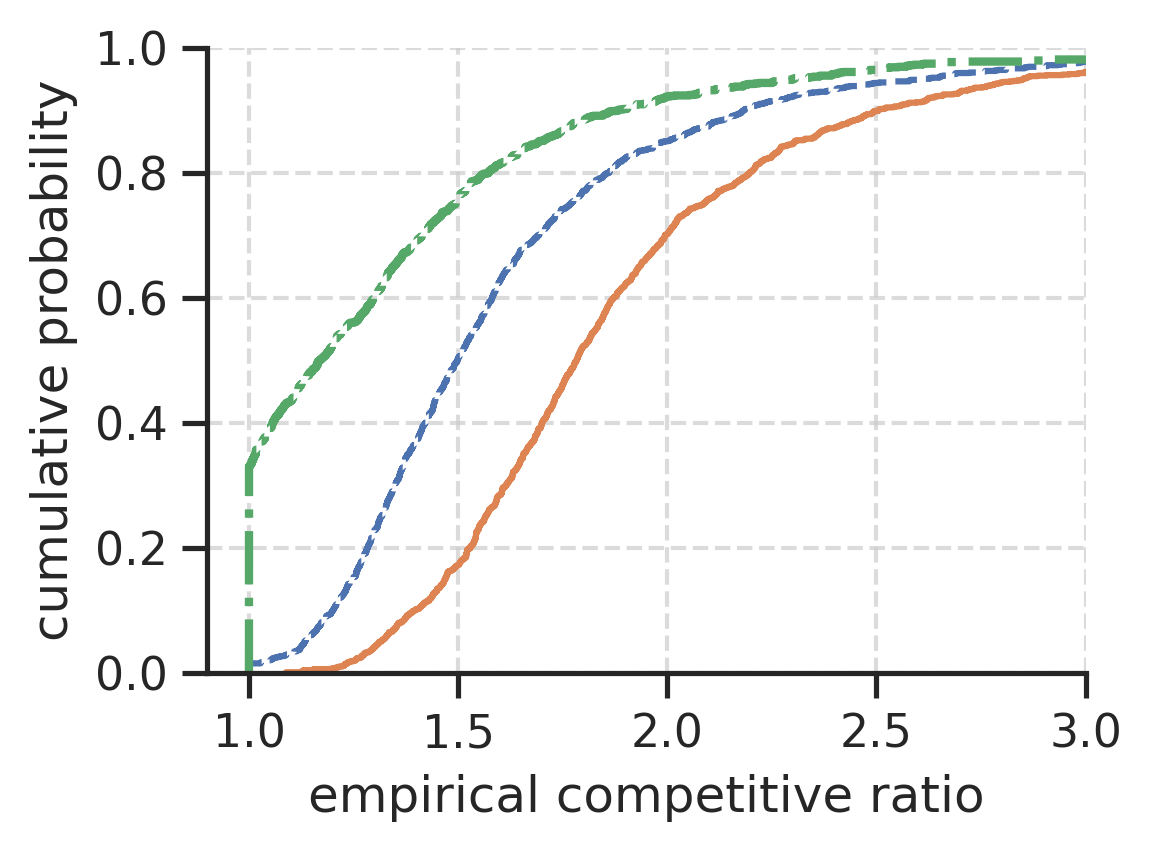

In [48]:
# plot a CDF of the main results in default open_results() -- use seaborn for nicer plots

labels = {"pald_over_opt": "PALD Simple", "paad_over_opt": "PAAD", "pald_contextual_over_opt": "PALD Contextual"}
linestyles = {"pald_over_opt": "dashed", "paad_over_opt": "solid", "pald_contextual_over_opt": "dashdot"}

# get the current color cycle from matplotlib
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = {"pald_over_opt": color_cycle[0], "paad_over_opt": color_cycle[1], "pald_contextual_over_opt": color_cycle[2]}

# specify markers for each method
markers = {"pald_over_opt": "o", "paad_over_opt": "s", "pald_contextual_over_opt": "^"}

rows = open_results(trace="ERCOT", T=48)
ratios_pald = [row['pald_over_opt'] for row in rows]
ratios_paad = [row['paad_over_opt'] for row in rows]
ratios_pald_contextual = None
if 'pald_contextual_over_opt' in rows[0]:
    ratios_pald_contextual = [row['pald_contextual_over_opt'] for row in rows]

plt.figure(figsize=(4,3), dpi=300)
sns.ecdfplot(ratios_pald, label=labels['pald_over_opt'], linewidth=1.5, linestyle=linestyles['pald_over_opt'])
sns.ecdfplot(ratios_paad, label=labels['paad_over_opt'], linewidth=1.5, linestyle=linestyles['paad_over_opt'])
if ratios_pald_contextual:
    sns.ecdfplot(ratios_pald_contextual, label=labels['pald_contextual_over_opt'], linewidth=2, linestyle=linestyles['pald_contextual_over_opt'])
plt.xlim(0.9, 3)
plt.ylim(0, 1)
plt.xlabel('empirical competitive ratio')
plt.ylabel('cumulative probability')
# plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
sns.despine()
plt.show()


Contextual results file eval_results/best_models_v1_ISONE_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Contextual results file eval_results/best_models_v1_PJM_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.


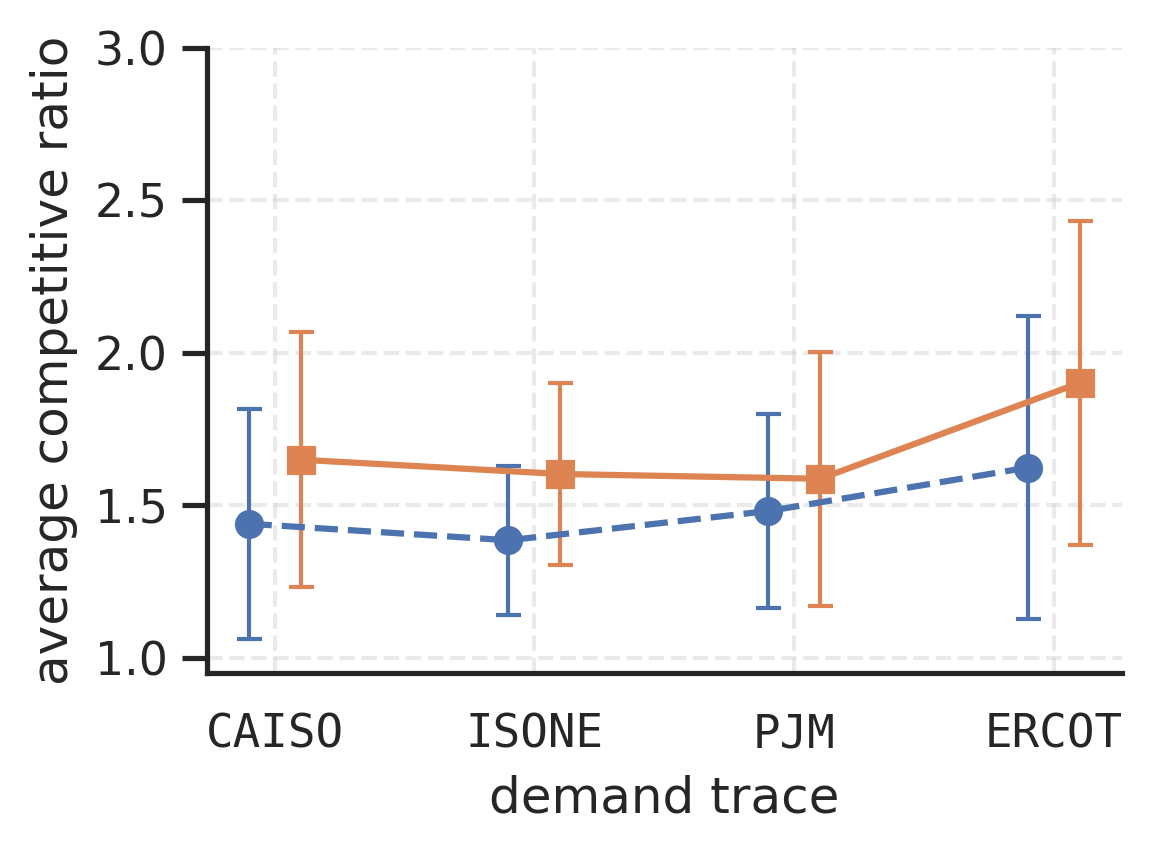

In [184]:
# plot the competitive ratios for different traces
traces = ["CAISO", "ISONE", "PJM", "ERCOT"]
avg_ratios_pald_trace = []
avg_ratios_paad_trace = []
avg_ratios_pald_contextual_trace = []
p95_ratios_pald_trace = []
p95_ratios_paad_trace = []
p95_ratios_pald_contextual_trace = []
std_ratios_pald_trace = []
std_ratios_paad_trace = []
std_ratios_pald_contextual_trace = []

for trace in traces:
    rows = open_results(trace=trace)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average, p95, and stddev of the ratios
    avg_ratios_pald_trace.append(statistics.mean(ratios_pald))
    p95_ratios_pald_trace.append(statistics.quantiles(ratios_pald, n=100)[94])
    std_ratios_pald_trace.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_trace.append(statistics.mean(ratios_paad))
    p95_ratios_paad_trace.append(statistics.quantiles(ratios_paad, n=100)[94])
    std_ratios_paad_trace.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_trace.append(statistics.mean(ratios_pald_contextual))
        p95_ratios_pald_contextual_trace.append(statistics.quantiles(ratios_pald_contextual, n=100)[94])
        std_ratios_pald_contextual_trace.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)

x = np.arange(len(traces))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)

width=0.25
# plot line for average with error bars for stddev
plt.errorbar(x - 0.1, avg_ratios_pald_trace, yerr=std_ratios_pald_trace, label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=3, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_trace, yerr=std_ratios_paad_trace, label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=3, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
# if avg_ratios_pald_contextual_trace:
#     plt.errorbar(x, avg_ratios_pald_contextual_trace, yerr=std_ratios_pald_contextual_trace, label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=3, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
    

# use monospace font for x labels
plt.xticks(x, traces, fontfamily='monospace')

plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('demand trace')
plt.tick_params(axis='x', which='both', bottom=False, top=False)
# plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

Loaded contextual results from eval_results/best_models_v1_CAISO_T24_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(150.7367534268661), 'paad_cost': np.float64(148.78298052128628), 'pald_delivered': 2.542452335357666, 'paad_delivered': 2.542444444444444, 'opt_cost': np.float64(91.17339967930299), 'opt_delivered': 2.5424444444444445, 'pald_over_opt': np.float64(1.6532974963868152), 'paad_over_opt': np.float64(1.631868297602388)}, {'instance': 1, 'pald_cost': np.float64(795.9966041474269), 'paad_cost': np.float64(1206.630868580728), 'pald_delivered': 8.72535514831543, 'paad_delivered': 9.147416666666665, 'opt_cost': np.float64(938.9906709783747), 'opt_delivered': 9.147416666666665, 'pald_over_opt': np.float64(0.8477151357830252), 'paad_over_opt': np.float64(1.2850296662942216)}, {'instance': 2, 'pald_cost': np.float64(809.0999183068974), 'paad_cost': np.float64(1045.159203530414), 'pald_delivered': 10.233598709106445, 'paad_delivered': 10.

/tmp/ipykernel_2261331/3710292313.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_deadline, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
/tmp/ipykernel_2261331/3710292313.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_deadline, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)


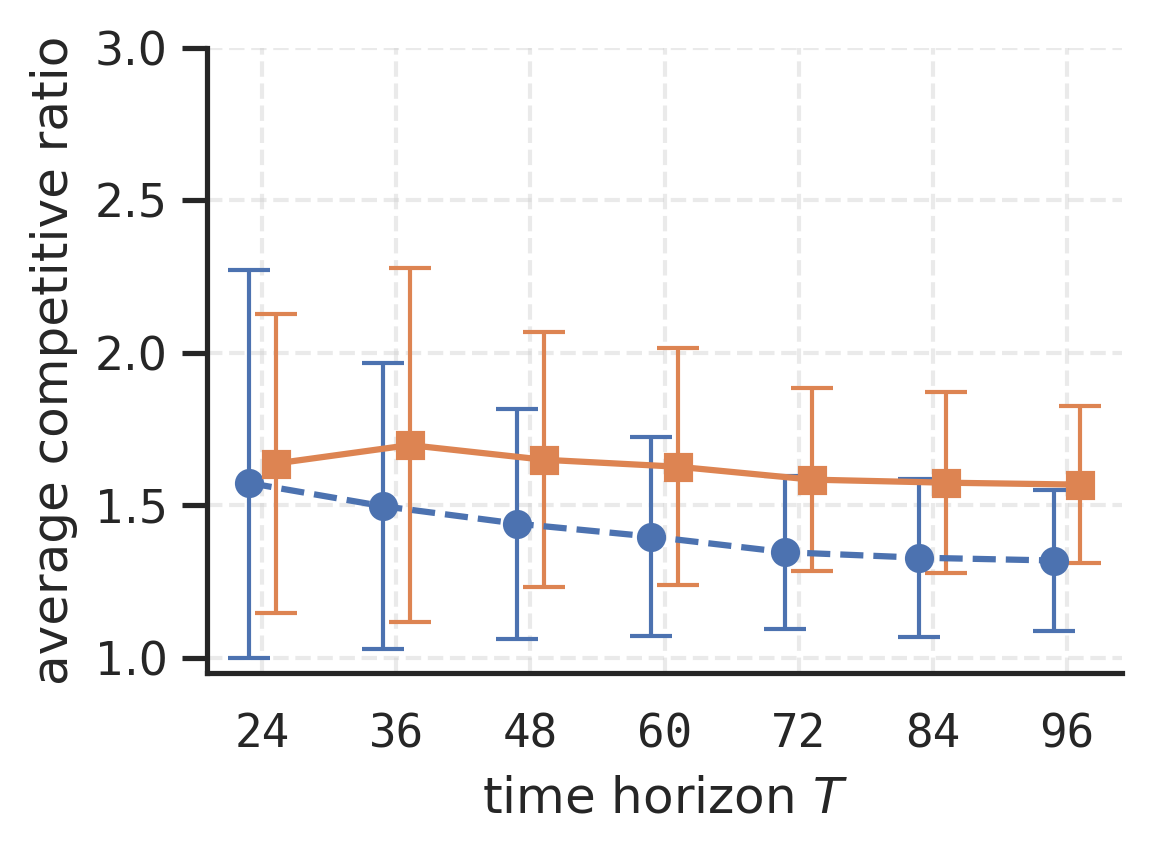

In [21]:
# plot the competitive ratios for different deadlines
Ts = [24, 36, 48, 60, 72, 84, 96]
avg_ratios_pald_deadline = []
avg_ratios_paad_deadline = []
avg_ratios_pald_contextual_deadline = []
std_ratios_pald_deadline = []
std_ratios_paad_deadline = []
std_ratios_pald_contextual_deadline = []

for T in Ts:
    rows = open_results(T=T)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_deadline.append(statistics.mean(ratios_pald))
    std_ratios_pald_deadline.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_deadline.append(statistics.mean(ratios_paad))
    std_ratios_paad_deadline.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_deadline.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_deadline.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(Ts))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_deadline, std_ratios_pald_deadline)], std_ratios_pald_deadline]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_deadline, std_ratios_paad_deadline)], std_ratios_paad_deadline]
plt.errorbar(x - 0.1, avg_ratios_pald_deadline, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_deadline, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
# if avg_ratios_pald_contextual_deadline:
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_deadline, std_ratios_pald_contextual_deadline)], std_ratios_pald_contextual_deadline]
#     plt.errorbar(x, avg_ratios_pald_contextual_deadline, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1.5, capthick=1, elinewidth=1)
plt.xticks(x, Ts, fontfamily='monospace')
plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('time horizon $T$')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

Contextual results file eval_results/best_models_v1_CAISO_T48_gamma0.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Contextual results file eval_results/best_models_v1_CAISO_T48_gamma5.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Loaded contextual results from eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(1670.5363482489392), 'paad_cost': np.float64(1813.2267028734618), 'pald_delivered': 11.001021385192871, 'paad_delivered': 11.491944444444446, 'opt_cost': np.float64(1284.7462392456184), 'opt_delivered': 11.491944444444446, 'pald_over_opt': np.float64(1.3002850658117904), 'paad_over_opt': np.float64(1.4113500763685118)}, {'instance': 1, 'pald_cost': np.float64(153.98704470373565), 'paad_cost': np.float64(157.93779871617087), 'pald_delivered': 1.315663456916809, 'paad_delivered': 1.5851944444444446, 'opt_cost': 

/tmp/ipykernel_2261331/275566993.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_gamma, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
/tmp/ipykernel_2261331/275566993.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_gamma, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)


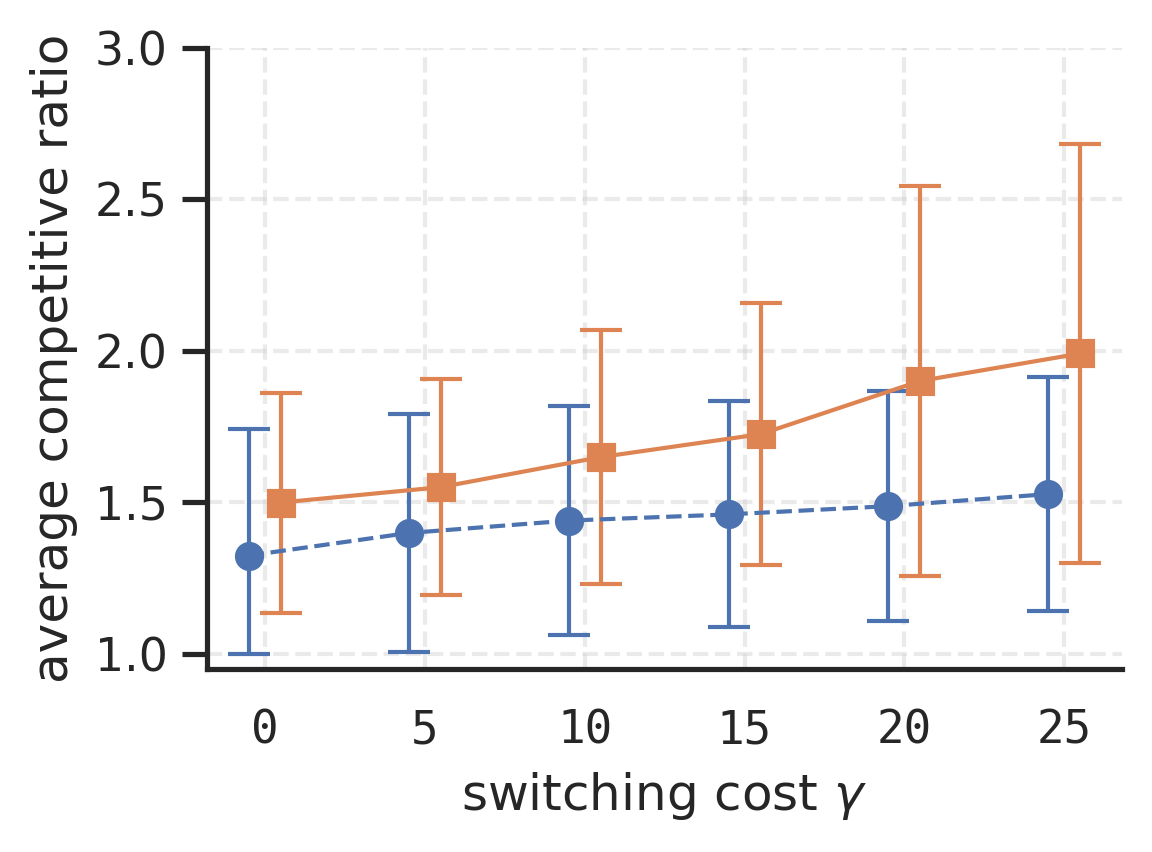

In [23]:
# plot the competitive ratios for different (grid-side) switching costs
gammas = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]
avg_ratios_pald_gamma = []
avg_ratios_paad_gamma = []
avg_ratios_pald_contextual_gamma = []
std_ratios_pald_gamma = []
std_ratios_paad_gamma = []
std_ratios_pald_contextual_gamma = []

for gamma in gammas:
    rows = open_results(gamma=gamma)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_gamma.append(statistics.mean(ratios_pald))
    std_ratios_pald_gamma.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_gamma.append(statistics.mean(ratios_paad))
    std_ratios_paad_gamma.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_gamma.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_gamma.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(gammas))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_gamma, std_ratios_pald_gamma)], std_ratios_pald_gamma]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_gamma, std_ratios_paad_gamma)], std_ratios_paad_gamma]
plt.errorbar(x - 0.1, avg_ratios_pald_gamma, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_gamma, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)
# if avg_ratios_pald_contextual_gamma:
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_gamma, std_ratios_pald_contextual_gamma)], std_ratios_pald_contextual_gamma]
#     plt.errorbar(x, avg_ratios_pald_contextual_gamma, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1)
# remove decimal points from x labels
gamma_labels = [str(int(g)) for g in gammas]
plt.xticks(x, gamma_labels, fontfamily='monospace')
plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('switching cost $\\gamma$')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()


Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta0.0_c0.2_eps0.05_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta2.5_c0.2_eps0.05_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Loaded contextual results from eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(1670.5363482489392), 'paad_cost': np.float64(1813.2267028734618), 'pald_delivered': 11.001021385192871, 'paad_delivered': 11.491944444444446, 'opt_cost': np.float64(1284.7462392456184), 'opt_delivered': 11.491944444444446, 'pald_over_opt': np.float64(1.3002850658117904), 'paad_over_opt': np.float64(1.4113500763685118)}, {'instance': 1, 'pald_cost': np.float64(153.98704470373565), 'paad_cost': np.float64(157.93779871617087), 'pald_delivered': 1.315663456916809, 'paad_delivered': 1.5851944444444446, 'opt_cost'

/tmp/ipykernel_2261331/154378602.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_delta, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
/tmp/ipykernel_2261331/154378602.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_delta, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)


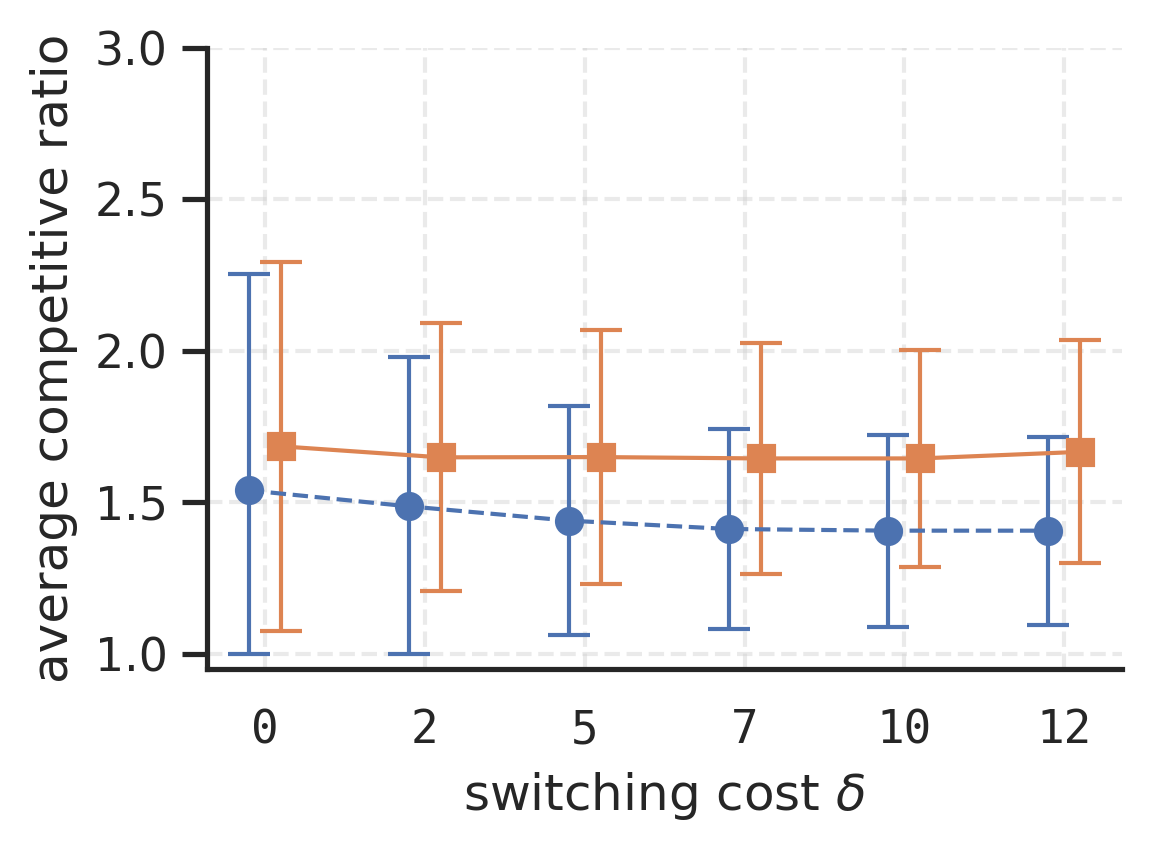

In [25]:
# plot the competitive ratios for different (demand-side) switching costs delta
deltas = [0.0, 2.5, 5.0, 7.5, 10.0, 12.5]
avg_ratios_pald_delta = []
avg_ratios_paad_delta = []
avg_ratios_pald_contextual_delta = []
std_ratios_pald_delta = []
std_ratios_paad_delta = []
std_ratios_pald_contextual_delta = []

for delta in deltas:
    rows = open_results(delta=delta)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_delta.append(statistics.mean(ratios_pald))
    std_ratios_pald_delta.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_delta.append(statistics.mean(ratios_paad))
    std_ratios_paad_delta.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_delta.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_delta.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(deltas))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_delta, std_ratios_pald_delta)], std_ratios_pald_delta]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_delta, std_ratios_paad_delta)], std_ratios_paad_delta]
plt.errorbar(x - 0.1, avg_ratios_pald_delta, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_delta, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)
# if avg_ratios_pald_contextual_delta:
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_delta, std_ratios_pald_contextual_delta)], std_ratios_pald_contextual_delta]
#     plt.errorbar(x, avg_ratios_pald_contextual_delta, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1)
# remove decimal points from x labels
delta_labels = [str(int(d)) for d in deltas]
plt.xticks(x, delta_labels, fontfamily='monospace')
plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('switching cost $\\delta$')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

Loaded contextual results from eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(1670.5363482489392), 'paad_cost': np.float64(1813.2267028734618), 'pald_delivered': 11.001021385192871, 'paad_delivered': 11.491944444444446, 'opt_cost': np.float64(1284.7462392456184), 'opt_delivered': 11.491944444444446, 'pald_over_opt': np.float64(1.3002850658117904), 'paad_over_opt': np.float64(1.4113500763685118)}, {'instance': 1, 'pald_cost': np.float64(153.98704470373565), 'paad_cost': np.float64(157.93779871617087), 'pald_delivered': 1.315663456916809, 'paad_delivered': 1.5851944444444446, 'opt_cost': np.float64(103.8409332331253), 'opt_delivered': 1.5851944444444446, 'pald_over_opt': np.float64(1.4829127580934887), 'paad_over_opt': np.float64(1.520958968671794)}, {'instance': 2, 'pald_cost': np.float64(300.14187677869785), 'paad_cost': np.float64(272.3591183410122), 'pald_delivered': 3.492949962615967, 'paad_delive

/tmp/ipykernel_2261331/3331268929.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_eta, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
/tmp/ipykernel_2261331/3331268929.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_eta, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)


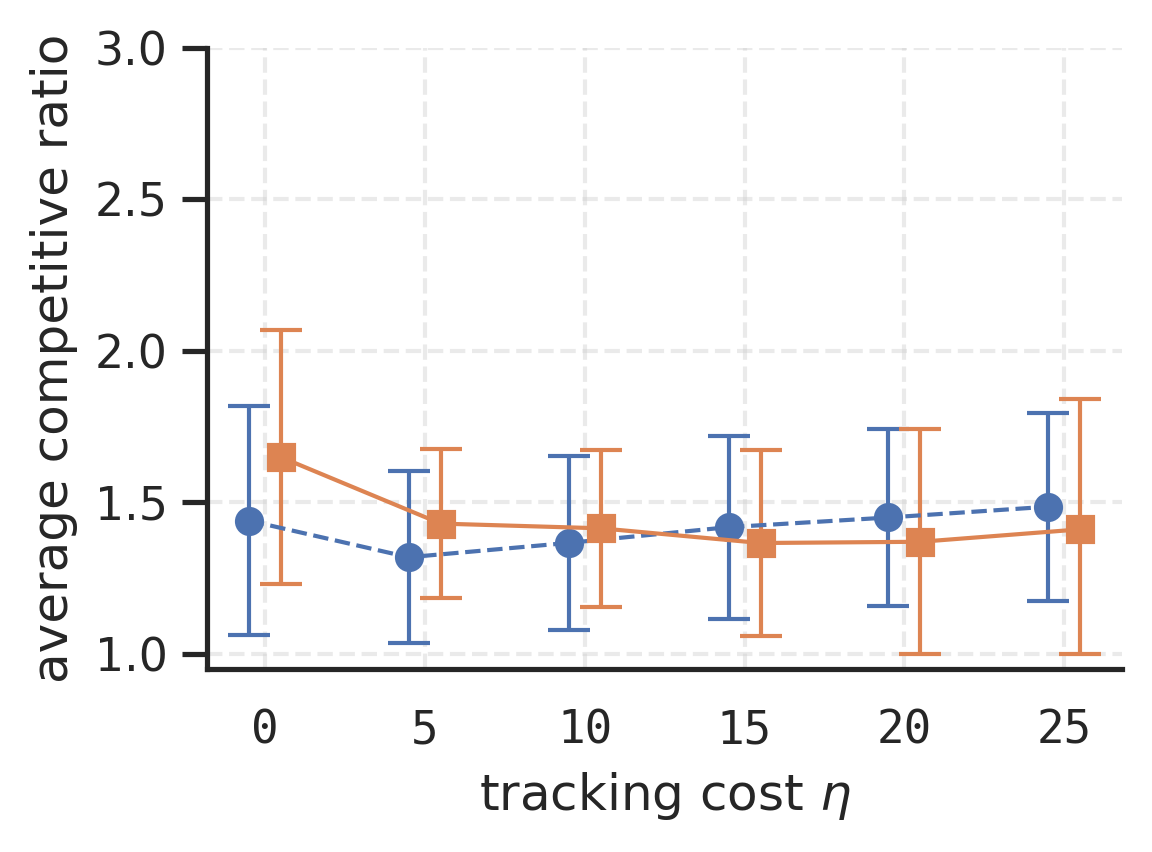

In [27]:
# plot the competitive ratios for different tracking costs eta
etas = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]
avg_ratios_pald_eta = []
avg_ratios_paad_eta = []
avg_ratios_pald_contextual_eta = []
std_ratios_pald_eta = []
std_ratios_paad_eta = []
std_ratios_pald_contextual_eta = []

for eta in etas:
    rows = open_results(eta=eta)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_eta.append(statistics.mean(ratios_pald))
    std_ratios_pald_eta.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_eta.append(statistics.mean(ratios_paad))
    std_ratios_paad_eta.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_eta.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_eta.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(etas))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_eta, std_ratios_pald_eta)], std_ratios_pald_eta]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_eta, std_ratios_paad_eta)], std_ratios_paad_eta]
plt.errorbar(x - 0.1, avg_ratios_pald_eta, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_eta, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)
# if avg_ratios_pald_contextual_eta:
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_eta, std_ratios_pald_contextual_eta)], std_ratios_pald_contextual_eta]
#     plt.errorbar(x, avg_ratios_pald_contextual_eta, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1)
# remove decimal points from x labels
eta_labels = [str(int(e)) for e in etas]
plt.xticks(x, eta_labels, fontfamily='monospace')
plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('tracking cost $\\eta$')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

Loaded contextual results from eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(1670.5363482489392), 'paad_cost': np.float64(1813.2267028734618), 'pald_delivered': 11.001021385192871, 'paad_delivered': 11.491944444444446, 'opt_cost': np.float64(1284.7462392456184), 'opt_delivered': 11.491944444444446, 'pald_over_opt': np.float64(1.3002850658117904), 'paad_over_opt': np.float64(1.4113500763685118)}, {'instance': 1, 'pald_cost': np.float64(153.98704470373565), 'paad_cost': np.float64(157.93779871617087), 'pald_delivered': 1.315663456916809, 'paad_delivered': 1.5851944444444446, 'opt_cost': np.float64(103.8409332331253), 'opt_delivered': 1.5851944444444446, 'pald_over_opt': np.float64(1.4829127580934887), 'paad_over_opt': np.float64(1.520958968671794)}, {'instance': 2, 'pald_cost': np.float64(300.14187677869785), 'paad_cost': np.float64(272.3591183410122), 'pald_delivered': 3.492949962615967, 'paad_delive

/tmp/ipykernel_2261331/489733106.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_scale, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
/tmp/ipykernel_2261331/489733106.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_scale, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)


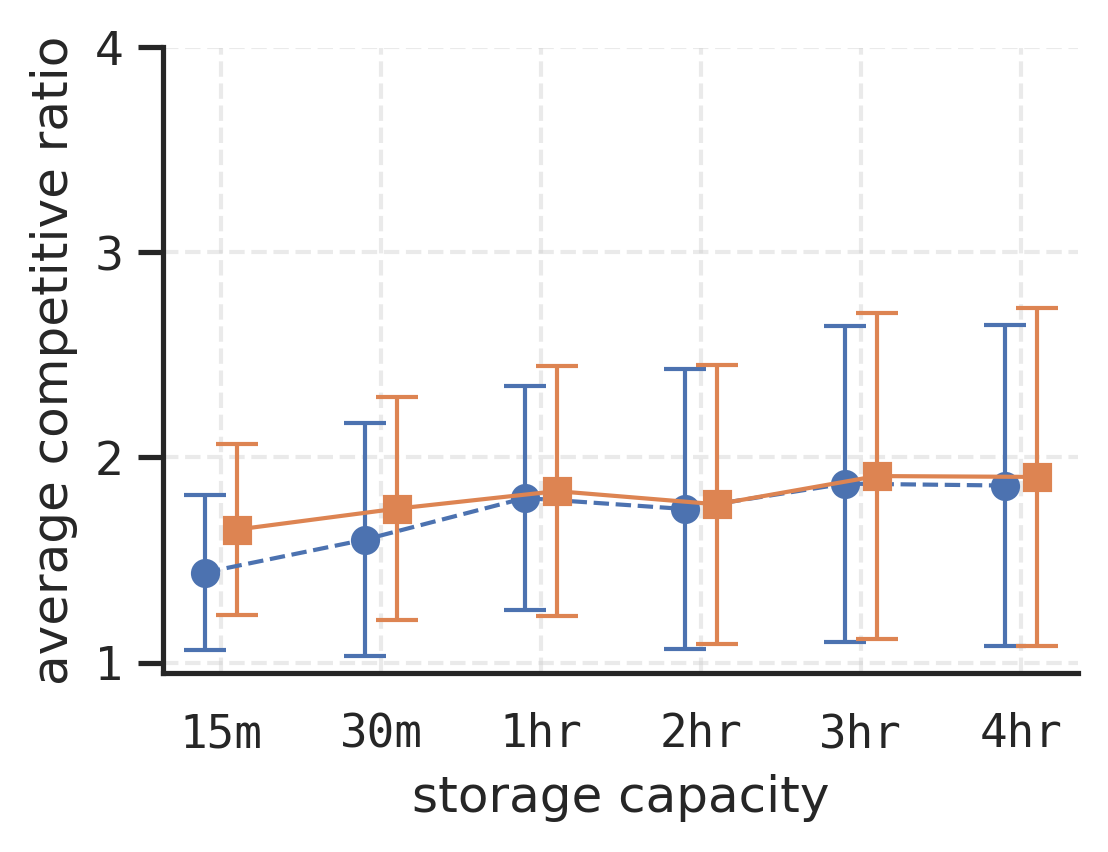

In [32]:
# plot the competitive ratios for different scale factors
scale_factors = [40.0, 80.0, 160.0, 320.0, 480.0, 640.0]
avg_ratios_pald_scale = []
avg_ratios_paad_scale = []
avg_ratios_pald_contextual_scale = []
std_ratios_pald_scale = []
std_ratios_paad_scale = []
std_ratios_pald_contextual_scale = []

for scale in scale_factors:
    rows = open_results(scale_factor=scale)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_scale.append(statistics.mean(ratios_pald))
    std_ratios_pald_scale.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_scale.append(statistics.mean(ratios_paad))
    std_ratios_paad_scale.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_scale.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_scale.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(scale_factors))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_scale, std_ratios_pald_scale)], std_ratios_pald_scale]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_scale, std_ratios_paad_scale)], std_ratios_paad_scale]
plt.errorbar(x - 0.1, avg_ratios_pald_scale, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_scale, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)
# if avg_ratios_pald_contextual_scale:
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_scale, std_ratios_pald_contextual_scale)], std_ratios_pald_contextual_scale]
#     plt.errorbar(x, avg_ratios_pald_contextual_scale, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1)
# remove decimal points from x labels
scale_labels = ["15m", "30m", "1hr", "2hr", "3hr", "4hr"]
plt.xticks(x, scale_labels, fontfamily='monospace')
plt.ylim(0.95, 4)
plt.ylabel('average competitive ratio')
plt.xlabel('storage capacity')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.001_eps0.0001_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Contextual results file eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.1_eps0.02_prop0.5_scale40.0.pkl does not exist. Skipping contextual results.
Loaded contextual results from eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(1670.5363482489392), 'paad_cost': np.float64(1813.2267028734618), 'pald_delivered': 11.001021385192871, 'paad_delivered': 11.491944444444446, 'opt_cost': np.float64(1284.7462392456184), 'opt_delivered': 11.491944444444446, 'pald_over_opt': np.float64(1.3002850658117904), 'paad_over_opt': np.float64(1.4113500763685118)}, {'instance': 1, 'pald_cost': np.float64(153.98704470373565), 'paad_cost': np.float64(157.93779871617087), 'pald_delivered': 1.315663456916809, 'paad_delivered': 1.5851944444444446, 'opt_c

/tmp/ipykernel_2261331/2745171349.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_delivery, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
/tmp/ipykernel_2261331/2745171349.py:35: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_delivery, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)


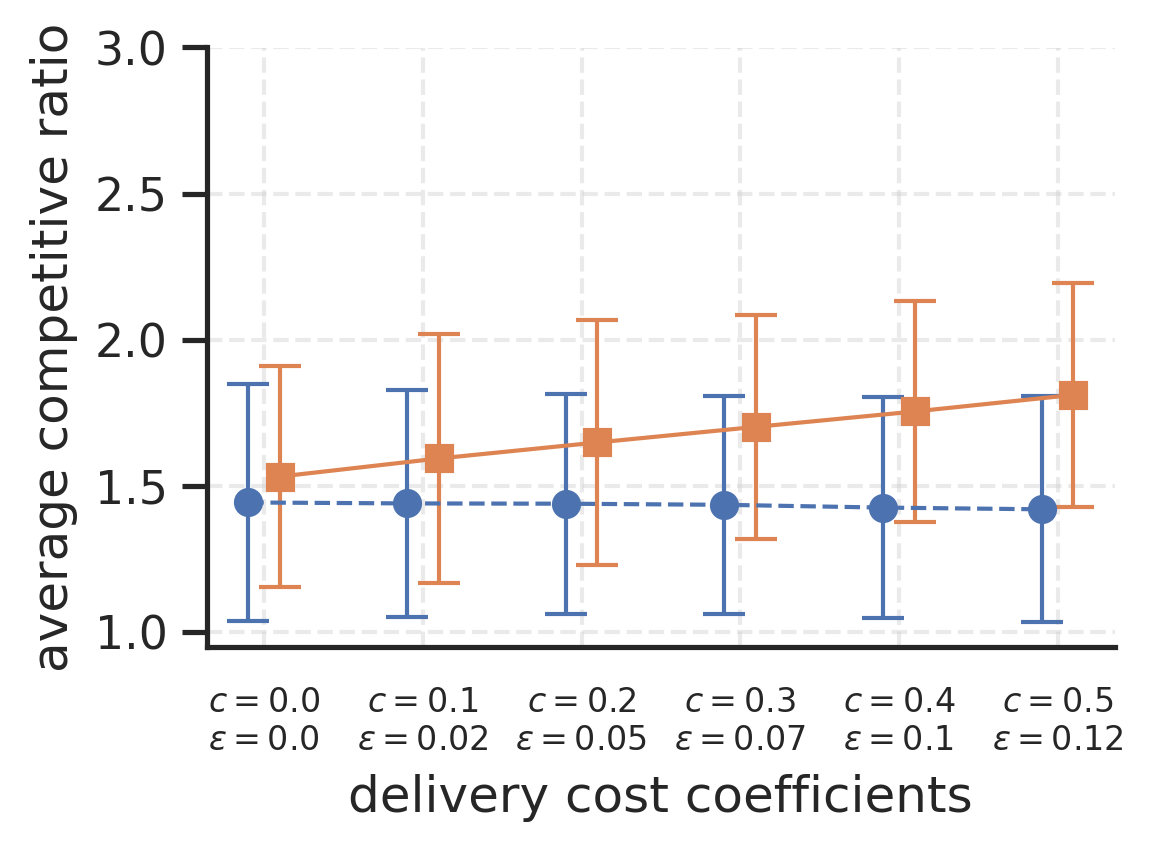

In [34]:
# plot the competitive ratios for different delivery costs
c_deliveries = [0.001, 0.1, 0.2, 0.3, 0.4, 0.5]
eps_deliveries = [0.0001, 0.02, 0.05, 0.07, 0.1, 0.12]
avg_ratios_pald_delivery = []
avg_ratios_paad_delivery = []
avg_ratios_pald_contextual_delivery = []
std_ratios_pald_delivery = []
std_ratios_paad_delivery = []
std_ratios_pald_contextual_delivery = []

for (c_delivery, eps_delivery) in zip(c_deliveries, eps_deliveries):
    rows = open_results(c_delivery=c_delivery, eps_delivery=eps_delivery)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_delivery.append(statistics.mean(ratios_pald))
    std_ratios_pald_delivery.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_delivery.append(statistics.mean(ratios_paad))
    std_ratios_paad_delivery.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_delivery.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_delivery.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(c_deliveries))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_delivery, std_ratios_pald_delivery)], std_ratios_pald_delivery]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_delivery, std_ratios_paad_delivery)], std_ratios_paad_delivery]
plt.errorbar(x - 0.1, avg_ratios_pald_delivery, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_delivery, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)
# if avg_ratios_pald_contextual_delivery: 
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_delivery, std_ratios_pald_contextual_delivery)], std_ratios_pald_contextual_delivery]
#     plt.errorbar(x, avg_ratios_pald_contextual_delivery, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1)
# remove decimal points from x labels
c_delivery_labels = [str(c) for c in c_deliveries]
eps_delivery_labels = [str(e) for e in eps_deliveries]
c_delivery_labels[0] = "0.0"
eps_delivery_labels[0] = "0.0"
# combine the two labels
combined_labels = [f"$c={c}$\n$\\varepsilon={e}$" for c, e in zip(c_delivery_labels, eps_delivery_labels)]
plt.xticks(x, combined_labels, fontfamily='monospace', fontsize=8)
plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('delivery cost coefficients')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
# plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

Loaded contextual results from eval_results/best_models_v1_CAISO_T48_gamma10.0_delta5.0_c0.2_eps0.05_prop0.5_scale40.0.pkl.
[{'instance': 0, 'pald_cost': np.float64(1670.5363482489392), 'paad_cost': np.float64(1813.2267028734618), 'pald_delivered': 11.001021385192871, 'paad_delivered': 11.491944444444446, 'opt_cost': np.float64(1284.7462392456184), 'opt_delivered': 11.491944444444446, 'pald_over_opt': np.float64(1.3002850658117904), 'paad_over_opt': np.float64(1.4113500763685118)}, {'instance': 1, 'pald_cost': np.float64(153.98704470373565), 'paad_cost': np.float64(157.93779871617087), 'pald_delivered': 1.315663456916809, 'paad_delivered': 1.5851944444444446, 'opt_cost': np.float64(103.8409332331253), 'opt_delivered': 1.5851944444444446, 'pald_over_opt': np.float64(1.4829127580934887), 'paad_over_opt': np.float64(1.520958968671794)}, {'instance': 2, 'pald_cost': np.float64(300.14187677869785), 'paad_cost': np.float64(272.3591183410122), 'pald_delivered': 3.492949962615967, 'paad_delive

/tmp/ipykernel_2261331/4276596477.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x - 0.1, avg_ratios_pald_demand, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
/tmp/ipykernel_2261331/4276596477.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x + 0.1, avg_ratios_paad_demand, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)


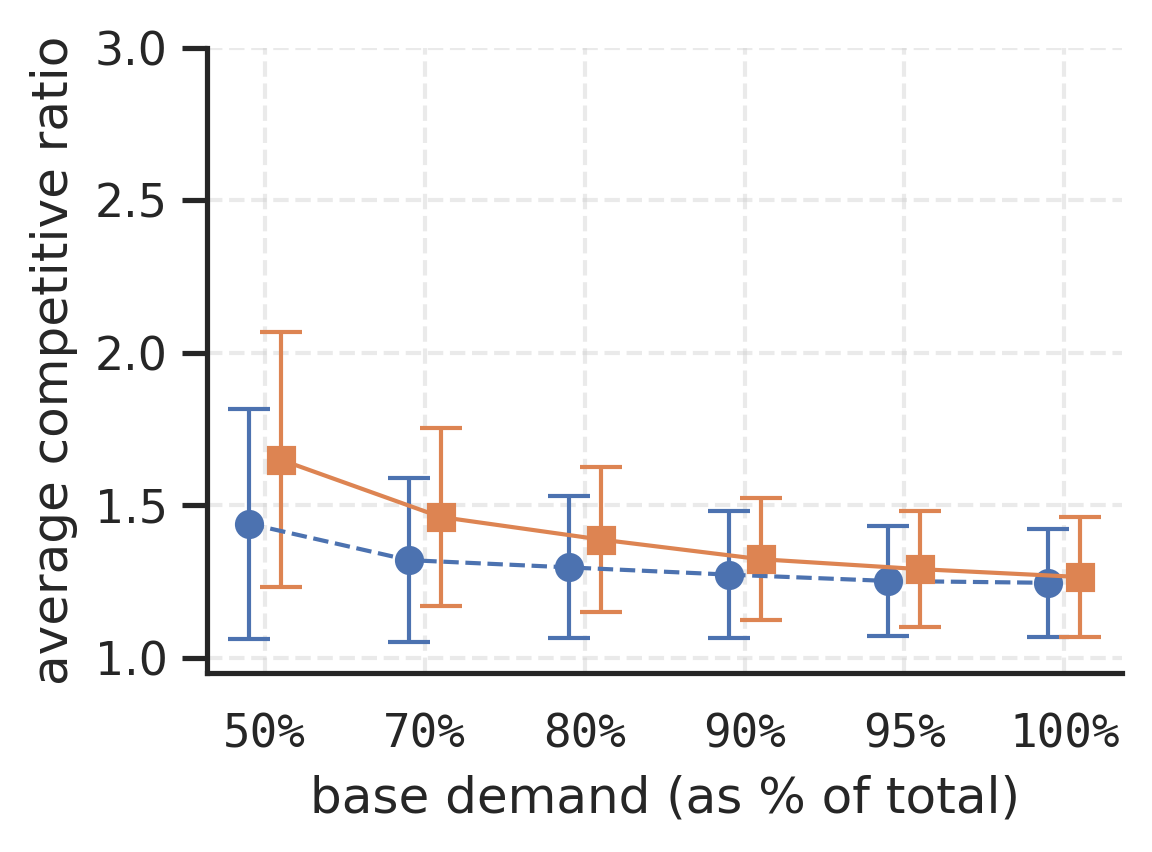

In [36]:
# plot the competitive ratios for different demand mixes
demand_props = [0.5, 0.7, 0.8, 0.9, 0.95, 1.0]
avg_ratios_pald_demand = []
avg_ratios_paad_demand = []
avg_ratios_pald_contextual_demand = []
std_ratios_pald_demand = []
std_ratios_paad_demand = []
std_ratios_pald_contextual_demand = []

for demand_prop in demand_props:
    rows = open_results(proportion_base=demand_prop)
    ratios_pald = [r["pald_over_opt"] for r in rows if r.get("pald_over_opt")]
    ratios_paad = [r["paad_over_opt"] for r in rows if r.get("paad_over_opt")]
    ratios_pald_contextual = None
    if rows and 'pald_contextual_over_opt' in rows[0]:
        ratios_pald_contextual = [r["pald_contextual_over_opt"] for r in rows if r.get("pald_contextual_over_opt")]
    # get the average and stddev of the ratios
    avg_ratios_pald_demand.append(statistics.mean(ratios_pald))
    std_ratios_pald_demand.append(statistics.stdev(ratios_pald) if len(ratios_pald) > 1 else 0.0)
    avg_ratios_paad_demand.append(statistics.mean(ratios_paad))
    std_ratios_paad_demand.append(statistics.stdev(ratios_paad) if len(ratios_paad) > 1 else 0.0)
    if ratios_pald_contextual:
        avg_ratios_pald_contextual_demand.append(statistics.mean(ratios_pald_contextual))
        std_ratios_pald_contextual_demand.append(statistics.stdev(ratios_pald_contextual) if len(ratios_pald_contextual) > 1 else 0.0)
x = np.arange(len(demand_props))  # the label locations
# plot line plots with error bars
plt.figure(figsize=(4,3), dpi=300)
# plot avg and std dev using error bars
# std dev is asymmetric (error bars cannot fall below 1.0 by definition), 
# so we need to compute the upper and lower error bars separately
yerr_pald = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_demand, std_ratios_pald_demand)], std_ratios_pald_demand]
yerr_paad = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_paad_demand, std_ratios_paad_demand)], std_ratios_paad_demand]
plt.errorbar(x - 0.1, avg_ratios_pald_demand, yerr=yerr_pald, fmt='o', label=labels['pald_over_opt'], color=colors['pald_over_opt'], linestyle=linestyles['pald_over_opt'], marker=markers['pald_over_opt'], capsize=5, markersize=6, linewidth=1)
plt.errorbar(x + 0.1, avg_ratios_paad_demand, yerr=yerr_paad, fmt='o', label=labels['paad_over_opt'], color=colors['paad_over_opt'], linestyle=linestyles['paad_over_opt'], marker=markers['paad_over_opt'], capsize=5, markersize=6, linewidth=1)
# if avg_ratios_pald_contextual_demand:
#     yerr_pald_contextual = [ [min(std, avg - 1.0) for avg, std in zip(avg_ratios_pald_contextual_demand, std_ratios_pald_contextual_demand)], std_ratios_pald_contextual_demand]
#     plt.errorbar(x, avg_ratios_pald_contextual_demand, yerr=yerr_pald_contextual, fmt='o', label=labels['pald_contextual_over_opt'], color=colors['pald_contextual_over_opt'], linestyle=linestyles['pald_contextual_over_opt'], marker=markers['pald_contextual_over_opt'], capsize=5, markersize=6, linewidth=1)
# remove decimal points from x labels
demand_labels = [str(int(d*100)) + "%" for d in demand_props]
plt.xticks(x, demand_labels, fontfamily='monospace')
plt.ylim(0.95, 3)
plt.ylabel('average competitive ratio')
plt.xlabel('base demand (as % of total)')
# disable ticks on x axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)
# plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
sns.despine()
plt.show()

(np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001),
 np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001))

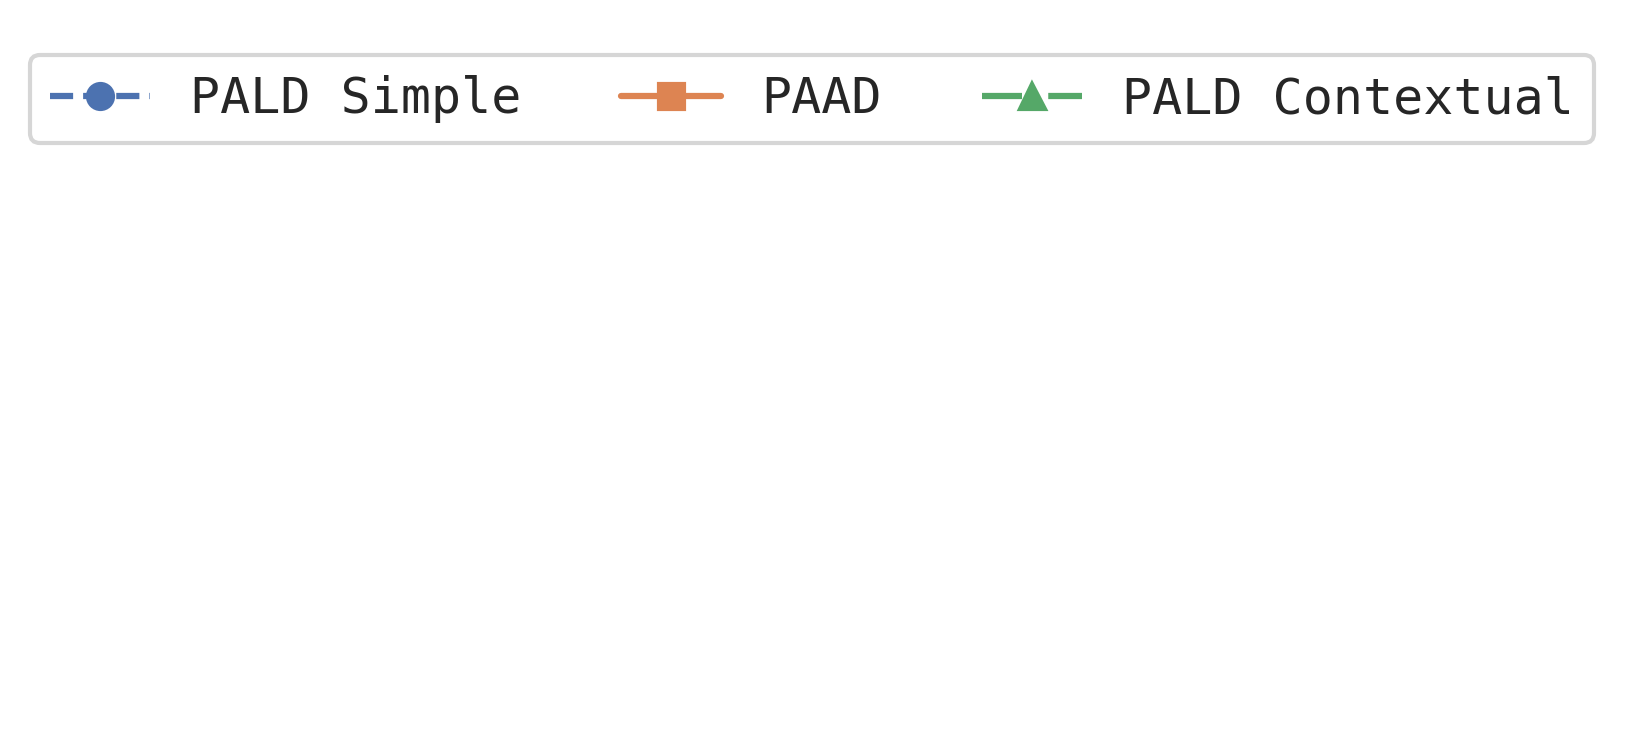

In [294]:
# plot dummy data for legend only
plt.figure(figsize=(4,3), dpi=300)
for key in labels.keys():
    plt.plot([], [], label=labels[key], color=colors[key], linestyle=linestyles[key], marker=markers[key])
plt.legend(fontsize=12, ncol=len(labels))
# use monospace font for legend labels
legend = plt.gca().get_legend()
for text in legend.get_texts():
    text.set_fontfamily('monospace')
plt.axis('off')